# Eruption/deposition age estimation demonstration

This Jupyter notebook demonstrates the eruption (/deposition) age estimation algorithm of [Keller, Schoene, and Samperton (2018)](https://doi.org/10.7185/geochemlet.1826) as adapted for use on Ar-Ar data by [van Zalinge et al. (2022)](https://doi.org/10.1038/s41586-022-04921-9) and implemented in [Chron.jl](https://github.com/brenhinkeller/Chron.jl)

<a href="https://mybinder.org/v2/gh/brenhinkeller/Chron.jl/main?filepath=examples%2FArClosureDistributionDemonstration.ipynb" target="_blank"><img src="https://static.mybinder.org/badge_logo.svg" alt="Launch Binder notebook" align="left"></a> 
<p style="text-indent: 5px">If running this notebook as an online Binder notebook and the webpage times out, click the badge at left to relaunch (refreshing will not work). Note that any changes will be lost!</p>

Hint: `shift`-`enter` to run a single cell, or from the `Cell` menu select `Run All` to run the whole file. Any code from this notebook can be copied and pasted into the Julia REPL or a `.jl` script.
***

## (1) Load required Julia packages

In [1]:
using Chron, Plots
using LsqFit: curve_fit
using KernelDensity: kde

***
## (2) Illustrate the derivation of the exponential closure distribution
#### We will begin by considering a set of highly dispersed Ar-Ar analyses
These files are located in [examples/ArArCompilation](https://github.com/brenhinkeller/Chron.jl/tree/main/examples/ArArCompilation)

In [2]:
nSamples = 11 # How many samples we have
smpl_ArAr = ChronAgeData(nSamples)
smpl_ArAr.Name = ("KBS", "Gele", "Chari", "Malbe", "Oxaya MZF16", "Molinos MZ707", "Cardones MZ10P", "Poconchile MZ317", "Mesa Falls 90116", "Mesa Falls 90118", "Bishop Tuff", )
smpl_ArAr.Path = "ArArCompilation/" # Where are the data files?,
smpl_ArAr.inputSigmaLevel = 1 # i.e., are the data files 1-sigma or 2-sigma. Integer.
smpl_ArAr.Age_Unit = "Ma" # Unit of measurement for ages and errors in the data files,

plotname = ("KBS (Phillips et al. 2023)", "Gele (Phillips et al. 2023)", "Chari (Phillips et al. 2023)", "Malbe (Phillips et al. 2023)", "Oxaya (van Zalinge et al. 2022)", "Molinos (van Zalinge et al. 2022)", "Cardones (van Zalinge et al. 2022)", "Poconchile (van Zalinge et al. 2022)", "MFT airfall (Ellis et al. 2017)", "MFT ignimbrite (Ellis et al. 2017)", "Bishop Tuff (Andersen et al. 2017)", );

#### Plot individual samples in terms of rank-order, CDF, and PDF

Bishop Tuff: 85.7 % included (42/49)
Mesa Falls 90118: 87.2 % included (89/102)
Mesa Falls 90116: 68.8 % included (31/45)
Poconchile MZ317: 79.0 % included (34/43)
Cardones MZ10P: 85.7 % included (36/42)
Molinos MZ707: 84.2 % included (32/38)
Oxaya MZF16: 85.0 % included (34/40)
Malbe: 86.6 % included (65/75)
Chari: 99.1 % included (115/116)
Gele: 97.9 % included (47/48)
KBS: 80.1 % included (85/106)


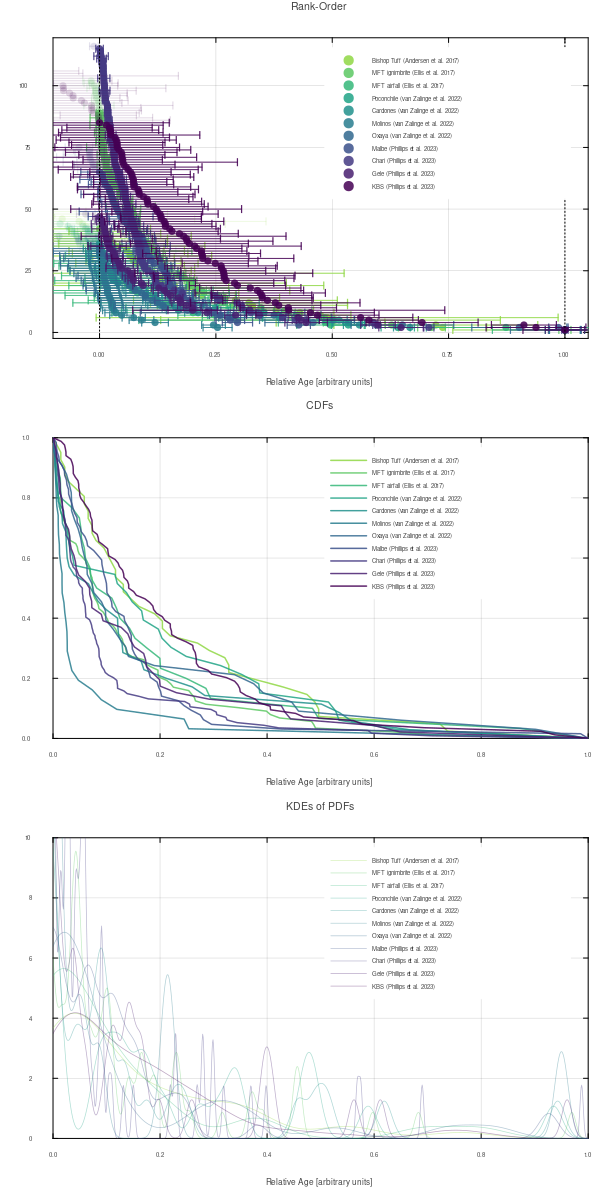

In [3]:
h1 = plot(framestyle=:box,
    title="Rank-Order",
    xlabel="Relative Age [arbitrary units]",
    ylabel="N",
    xlims=(-0.1, 1.05),
    fg_color_legend=:white,
    fontfamily=:Helvetica,
)

h2 = plot(framestyle=:box,
    title="CDFs",
    xlabel="Relative Age [arbitrary units]",
    ylabel="Cumulative Probability",
    xlims=(0, 1),
    ylims=(0, 1),
    fg_color_legend=:white,
    fontfamily=:Helvetica,
)

h3 = plot(xlims=(0,1),
    title="KDEs of PDFs",
    xlabel="Relative Age [arbitrary units]",
    ylabel="Probability Density",
    fg_color_legend=:white,
    framestyle=:box,
    fontfamily=:Helvetica,
)

# Choice of colormap
n = 2
cmap = resize_colormap(viridis,nSamples+n)[1:end-n]
# Slight additional truncation to ensure we aren't seeing excess analytical uncertainty
xmin = 0.03

# Cycle through samples from last to first
for i = nSamples:-1:1
    # Read data from file
    data = importdataset("$(smpl_ArAr.Path)$(smpl_ArAr.Name[i]).csv", elements=("μ", "σ"), importas=:Tuple)
    data.σ./=smpl_ArAr.inputSigmaLevel

    sI = sortperm(data.μ, rev=true)
    permute!(data.μ, sI)
    permute!(data.σ, sI)

    # Maximum extent of expected analytical tail (beyond eruption/deposition)
    maxTailLength = nanmean(data.σ) * norm_quantile(1-1/(length(data.μ) + 1))
    included = (data.μ .- minimum(data.μ)) .>= maxTailLength
    print("$(smpl_ArAr.Name[i]): $(trunc(sum(included)/length(included)*100, digits=1)) % included ($(sum(included))/$(length(included)))\n")

    l, u = extrema(data.μ[included])
    x = (data.μ .- l)/(u-l)
    y = 1:length(data.μ)

    plot!(h1, x, y,
        xerror=2*data.σ/(u-l),
        color=cmap[i],
        mscolor=cmap[i],
        label="",
        seriestype=:scatter,
        alpha=0.15,
    )
    plot!(h1, x[included], y[included],
        xerror=2*data.σ[included]/(u-l),
        color=cmap[i],
        mscolor=cmap[i],
        label=plotname[i],
        seriestype=:scatter,
        alpha=0.85,
    )

    x = (data.μ[included] .- l)/(u-l)
    y = range(0,1,length=count(included))
    plot!(h2, x, y,
        color=cmap[i],
        mscolor=cmap[i],
        label=plotname[i],
        linewidth=1.5,
        alpha=0.85,
    )

    kd = kde(x,npoints=2^10,bandwidth=nanmean(data.σ[included])/(u-l))
    # kd = kde(x,npoints=2^10)

    t = kd.x .> xmin
    dist = kd.density[t]
    dist = dist./nanmean(dist)

    # Plot bootstrapped distribution
    plot!(h3,range(0,1,length=length(dist)),dist,
        label=plotname[i],
        linecolor=cmap[i],
        linealpha=0.35,
        linewidth=0.75,
    )
end

vline!(h1, [0, 1], color=:black, style=:dot, label="")
ylims!(h3, 0,10)

hc = plot(h1, h2, h3, layout=(3,1), size=(600,1200))
display(hc)

#### Calculate bootstrapped $\ \mathcal{\vec{f}}_{xtal}(t_r)$
The resulting exponential  `ArClosureDistribution` is equivalent to the `ExponentialDistribution` included in Chron.jl

┌ Info: Interpreting first two columns of KBS.csv as 
└  | Age | Age 1-sigma 𝑎𝑏𝑠𝑜𝑙𝑢𝑡𝑒 |
┌ Info: Interpreting first two columns of Gele.csv as 
└  | Age | Age 1-sigma 𝑎𝑏𝑠𝑜𝑙𝑢𝑡𝑒 |
┌ Info: Interpreting first two columns of Chari.csv as 
└  | Age | Age 1-sigma 𝑎𝑏𝑠𝑜𝑙𝑢𝑡𝑒 |
┌ Info: Interpreting first two columns of Malbe.csv as 
└  | Age | Age 1-sigma 𝑎𝑏𝑠𝑜𝑙𝑢𝑡𝑒 |
┌ Info: Interpreting first two columns of Oxaya MZF16.csv as 
└  | Age | Age 1-sigma 𝑎𝑏𝑠𝑜𝑙𝑢𝑡𝑒 |
┌ Info: Interpreting first two columns of Molinos MZ707.csv as 
└  | Age | Age 1-sigma 𝑎𝑏𝑠𝑜𝑙𝑢𝑡𝑒 |
┌ Info: Interpreting first two columns of Cardones MZ10P.csv as 
└  | Age | Age 1-sigma 𝑎𝑏𝑠𝑜𝑙𝑢𝑡𝑒 |
┌ Info: Interpreting first two columns of Poconchile MZ317.csv as 
└  | Age | Age 1-sigma 𝑎𝑏𝑠𝑜𝑙𝑢𝑡𝑒 |
┌ Info: Interpreting first two columns of Mesa Falls 90116.csv as 
└  | Age | Age 1-sigma 𝑎𝑏𝑠𝑜𝑙𝑢𝑡𝑒 |
┌ Info: Interpreting first two columns of Mesa Falls 90118.csv as 
└  | Age | Age 1-sigma 𝑎𝑏𝑠𝑜𝑙𝑢𝑡𝑒 |
┌ Info: Interpreting first two columns of Bisho

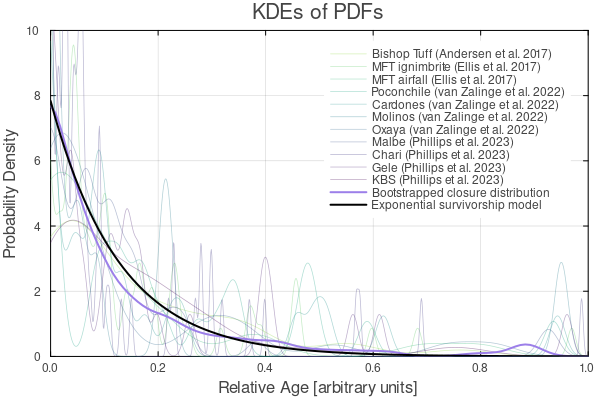

In [4]:
# Bootstrap the closure distribution
dist = BootstrapCrystDistributionKDE(smpl_ArAr, cutoff=xmin)
dist = dist./nanmean(dist) # Normalize
trel = range(0,1,length=length(dist)) # X-axis
plot!(h3, trel, dist, label="Bootstrapped closure distribution",linewidth=2)

# Exponential survivorship model suggests form  y = A*exp(-λ*t)
# Normalization requires A == λ
f(x,λ) = λ[1] .* exp.(-λ[1] .* x)
λ = [5.0,] # initial guess
fobj = curve_fit(f,trel,dist,λ) # Fit nonlinear model
λ = fobj.param
ArClosureDistribution = f(trel,λ) 
plot!(h3,trel,ArClosureDistribution, label="Exponential survivorship model",linewidth=2,color=:black)

***
## (3) Estimate eruption age for an Ar-Ar dataset
The example dataset here is from [Ellis et al. 2017](http://dx.doi.org/10.1016/j.chemgeo.2017.03.005) on the Mesa Falls Tuff (90118)
#### Input dataset (Try pasting in your own data here!)

In [5]:
# Age and one-sigma uncertainty.
ages = [1.4007, 1.2988, 1.3154, 1.4357, 1.3021, 1.3509, 1.2971, 1.3019, 1.3397, 1.3037, 1.345, 1.357, 1.3332, 1.3031, 1.3487, 1.4677, 1.3024, 1.3029, 1.4932, 1.3007, 1.3085, 1.3044, 1.2981, 1.3219, 1.3958, 1.2986, 1.4268, 1.2978, 1.4639, 1.3534, 1.2925, 1.2947, 1.3999, 1.446, 1.3173, 1.354, 1.2992, 1.3553, 1.3439, 1.308, 1.3083, 1.294, 1.293, 1.3628, 1.2894, 1.6173, 1.4988, 1.3539, 2.0522, 1.2931, 1.4263, 1.2848, 1.3302, 1.319, 1.836, 1.3013, 1.3745, 1.5596, 1.3113, 1.4581, 1.3001, 1.3023, 1.335, 1.6681, 1.2846, 1.6044, 1.3214, 1.3324, 1.2956, 1.3687, 1.3825, 1.3531, 1.4973, 1.3202, 1.3084, 1.4468, 1.3863, 1.3532, 1.3012, 1.4088, 1.35, 1.3126, 1.402, 1.6656, 1.3716, 1.3882, 1.3008, 1.7715, 1.3619, 1.2959, 1.5987, 1.2979, 1.4894, 1.3051, 1.3092, 1.5137, 1.36, 1.6624, 1.3764, 1.3929, 1.446, 1.3968]
uncert = [0.0035, 0.008, 0.0028, 0.0042, 0.0046, 0.0028, 0.0122, 0.0029, 0.0062, 0.0029, 0.0025, 0.0026, 0.0026, 0.013, 0.0199, 0.004, 0.0052, 0.0033, 0.004, 0.0091, 0.0072, 0.0028, 0.0027, 0.0052, 0.0028, 0.0033, 0.0036, 0.0042, 0.0037, 0.0041, 0.0074, 0.0048, 0.0042, 0.0036, 0.0031, 0.0052, 0.0032, 0.0038, 0.0034, 0.0031, 0.0032, 0.0027, 0.0027, 0.0036, 0.0039, 0.0041, 0.0032, 0.0043, 0.0049, 0.0032, 0.0058, 0.0059, 0.0043, 0.0028, 0.0112, 0.0057, 0.0032, 0.011, 0.003, 0.0404, 0.0037, 0.0046, 0.0043, 0.0037, 0.0068, 0.0054, 0.0043, 0.0028, 0.0034, 0.0043, 0.0037, 0.0055, 0.004, 0.0027, 0.0055, 0.0031, 0.0307, 0.0052, 0.0045, 0.0041, 0.0074, 0.0046, 0.0073, 0.0077, 0.0076, 0.0064, 0.0038, 0.0052, 0.0041, 0.0051, 0.0217, 0.0068, 0.0046, 0.0055, 0.0052, 0.0053, 0.0074, 0.0052, 0.0043, 0.0059, 0.0049, 0.0054]

# Sort by age (just to make rank-order plots prettier)
t = sortperm(ages)
permute!(ages, t);
permute!(uncert, t);

#### Run MCMC to estimate eruption age


Estimated eruption age:
 1.2922084842042572 +/- 0.0045732432542749625 Ma (2σ)
 1.29221 +0.0035/-0.0052 Ma (95% CI)

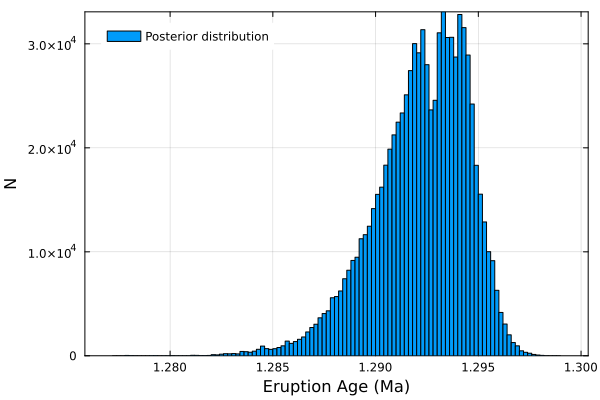

In [6]:
# Configure model
nsteps = 1000000; # Length of Markov chain
burnin = 150000; # Number of steps to discard at beginning of Markov chain

# Choose the form of the prior closure/crystallization distribution to use
dist = ExponentialDistribution          # Applicable for survivorship processes, potentially including inheritance/dispersion in Ar-Ar dates

# Run MCMC
tminDist = metropolis_min(nsteps,dist,ages,uncert);

# Print results
AgeEst = nanmean(tminDist);
AgeEst_sigma = nanstd(tminDist);
ci = CI(tminDist)
flush(stdout)
print("\nEstimated eruption age:\n $AgeEst +/- $(2*AgeEst_sigma) Ma (2σ)\n $ci Ma (95% CI)")

# Plot results
h = histogram(tminDist[burnin:end],nbins=100,label="Posterior distribution",xlabel="Eruption Age (Ma)",ylabel="N",legend=:topleft,fg_color_legend=:white, framestyle=:box)
display(h)
sleep(0.5)

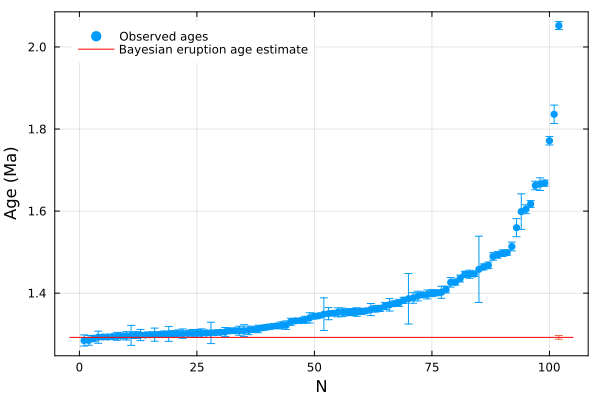

In [7]:
# Plot eruption age estimate relative to rank-order plot of raw zircon ages
h = plot(framestyle=:box,
    ylabel="Age (Ma)", 
    xlabel="N", 
    legend=:topleft, 
    fg_color_legend=:white,
)
plot!(h,1:length(ages),ages,yerror=uncert*2,seriestype=:scatter, markerstrokecolor=:auto, label="Observed ages")
plot!(h,[length(ages)],[AgeEst],yerror=2*AgeEst_sigma, markerstrokecolor=:auto, label="Bayesian eruption age estimate",color=:red)
plot!(h,collect(xlims()),[AgeEst,AgeEst],color=:red, label="")

***